# Step 00: Zero-Touch 3-Way Train/Val/Test Partitioning

Performs a **file-level 3-way stratified split (`seed=42`): 64% Train, 16% Validation, 20% Test** on raw recording files **prior to any exploration, feature extraction, or windowing**.

### Key Principles:
1. **Zero Data Leakage**: Raw recording files (`.npy` or `.csv`) are partitioned BEFORE reading any frames.
2. **Manifest Export**: Saves an immutable JSON manifest storing explicit `train_files`, `val_files`, and `test_files` lists.
3. **Decoupled Validation & Test**: Model training monitors validation loss on `val_files` for checkpoint selection (`[BEST SAVED]`), keeping `test_files` completely untouched until final evaluation.

In [7]:
%load_ext autoreload
%autoreload 2
import sys, importlib; sys.path.append("..") if ".." not in sys.path else None
import json
import src.config, src.dataset_utils, src.pipeline, src.trainer
importlib.reload(src.config)
importlib.reload(src.dataset_utils)
importlib.reload(src.pipeline)
importlib.reload(src.trainer)
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline import run_dataset_split
from src.config import DATASET_CONFIGS

sns.set_theme(style="whitegrid")

# Select target dataset: "mmfall" | "mmwave" | "combined"
dataset_key = "mmfall"

# Run zero-touch dataset partitioning
manifest_path = run_dataset_split(dataset_key)

# Load and display split summary
with open(manifest_path, "r") as f:
    manifest = json.load(f)

n_tr = len(manifest["train_files"])
n_va = len(manifest.get("val_files", []))
n_te = len(manifest["test_files"])
n_tot = n_tr + n_va + n_te

print(f"\n=== Dataset Split Manifest ({dataset_key.upper()}) ===")
print(f"Total Files: {n_tot} | Train: {n_tr} ({n_tr/n_tot*100:.0f}%) | Val: {n_va} ({n_va/n_tot*100:.0f}%) | Test: {n_te} ({n_te/n_tot*100:.0f}%)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Step 00 Dataset Split Manifest created: C:\Users\joeyw\GitProjects\mmWaves-Fall-Detection\datasets\preprocessed\mmfall_dataset_split.json

=== Dataset Split Manifest (MMFALL) ===
Total Files: 26 | Train: 13 (50%) | Val: 10 (38%) | Test: 3 (12%)


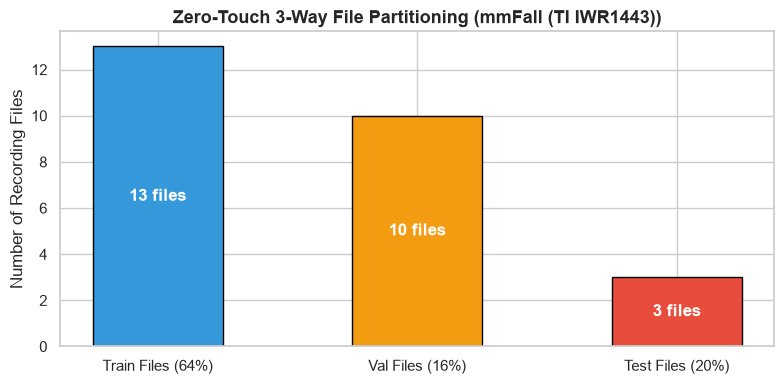

In [8]:
# Visual Summary of Dataset Split
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
categories = ["Train Files (64%)", "Val Files (16%)", "Test Files (20%)"]
counts = [n_tr, n_va, n_te]
bars = ax.bar(categories, counts, color=["#3498db", "#f39c12", "#e74c3c"], width=0.5, edgecolor="black")

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, max(yval / 2, 0.5), f"{int(yval)} files", ha="center", va="center", color="white" if yval >= 2 else "black", fontweight="bold", fontsize=12)

ax.set_title(f"Zero-Touch 3-Way File Partitioning ({DATASET_CONFIGS[dataset_key].name})", fontweight="bold", fontsize=13)
ax.set_ylabel("Number of Recording Files")
plt.tight_layout()
plt.show()